# IMPORTANT:

Can maybe incorporate the actual patient type!

# Preparing stuff

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib import ticker
import plotly.graph_objects as go

import numpy as np
import pandas as pd
import seaborn as sns
import os
import math


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc, brier_score_loss, pairwise_distances, silhouette_samples, precision_score, recall_score, silhouette_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier # Multi layer perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay, partial_dependence
from sklearn.utils import shuffle
from sklearn.calibration import calibration_curve
from sklearn.tree import plot_tree
from sklearn.cross_decomposition import PLSRegression

import shap
from scipy.stats import binomtest, binom_test, ttest_ind, mannwhitneyu
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram

from joblib import Parallel, delayed
import pickle



In [2]:
from subject import Subject
from util import *
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

def compute_trend_features(values):
    # Infer time points based on length
    time = np.arange(len(values)).reshape(-1, 1)  # [0, 1, 2, ..., N-1]
    values = np.array(values)

    # Linear Regression Slope
    model = LinearRegression().fit(time, values)
    slope = model.coef_[0]  # Extract slope

    # Spearman Correlation
    spearman_corr, _ = spearmanr(time.flatten(), values)

    return slope, spearman_corr

def compute_burstiness(irt):
    """Compute burstiness measure (b) for a sequence of inter-response times (IRT)."""
    mu = np.mean(irt)
    sigma = np.std(irt)
    
    if mu + sigma == 0:  # Avoid division by zero
        print(f"mu + sigma is zero for irt: {irt}")
        return np.nan
    
    return (sigma - mu) / (sigma + mu)


In [3]:
# NOTE: the commented part is getting all the variables (columns as in the original data)
# NOTE: The one not commented is the same but with getting only the variables that I want to keep
# subjects = Subject.get_healthy_controls()
# runs = range(1,3)
# blocks_per_run = range(1,11)
# # Create A DF of all the subjects
# all_subjects_df = {}
# for sub in subjects:
#     all_subjects_df[sub.subid] = {'all_data': pd.read_csv(get_trial_info(sub.subid)), 'blocks': {}}
#     for run in runs:
#         for block in blocks_per_run:
#             all_subjects_df[sub.subid]['blocks'][(run-1)*10+block] = get_block(sub.subid, run, block)

pd.set_option('display.max_columns', None)
# show all rows:
pd.set_option('display.max_rows', None)
# all_subjects_df.head()

vars_to_keep = ['participant', 'run', 'trial', 'trial_num_python', 'event', 'duration', 'routineClock_t', 'resp', 'corrResp', 'wasRnf', 'outcome', 'cond_val', 'phase', 'position', 'condition', 'nResp_untilRnf', 'list','devalued_coin', 'date']

subjects = Subject.get_healthy_controls()
runs = range(1,3)
blocks_per_run = range(1,11)
# Create A DF of all the subjects
all_subjects_df = {}
for sub in subjects:
    all_sub_data = pd.read_csv(get_trial_info(sub.subid)).loc[:,vars_to_keep]
    all_subjects_df[sub.subid] = {'all_data': all_sub_data, 'blocks': {}, 'runs': {}}
    for run in runs:
        # fill in runs
        all_subjects_df[sub.subid]['runs'][run] = all_sub_data[all_sub_data['run'] == run-1]
        # fill in blocks
        for block in blocks_per_run:
            all_subjects_df[sub.subid]['blocks'][(run-1)*10+block] = get_block(sub.subid, run, block).loc[:,vars_to_keep]


# patients = Subject.get_patients()
# patients_subIDs = [patient.subid for patient in patients]



In [4]:
# NOTE: PLAN AND OPTIONS
# ---------------------------------------------------------
# Vars to keep: run event duration routineClock_t trial nResp_untilRnf corrResp resp wasRnf participant date outcome	cond_val phase devalued_coin position condition list	trial_num_python

#.. right or wrong action..... calculate
# maybe also volatility..

# Advanced, maybe later:
# Maybe difference in response patterns for different stimulus types and maybe different responses.
# How reward non reward affect next actions/patterns of actinos...
# day of the week by date say, and there is also time at day I think...
# Consumption test/s data...
# change between blocks info, differences between different stimulus types...
# MAybe get data for say first block as different set of features..
# Get a measure of "anticipation to reward" by tracking pattern of actions between rewards... (e.g. reduction in RT intervals...)

all_subjects_df[2]['all_data'].head()



,participant,run,trial,trial_num_python,event,duration,routineClock_t,resp,corrResp,wasRnf,outcome,cond_val,phase,position,condition,nResp_untilRnf,list,devalued_coin,date
0,2.0,0.0,NaN,0.0,instr_before_block,6.0,NaN,NaN,left,NaN,silver,deval,training,"[0.5, 0]",resp1,NaN,2.0,silver,2020_Feb_18_1814
1,2.0,0.0,0.0,0.0,training_period_start,37.5,0.000000,NaN,left,NaN,silver,deval,training,"[0.5, 0]",resp1,11.0,2.0,silver,2020_Feb_18_1814
2,2.0,0.0,0.0,0.0,training_resp,NaN,0.848891,right,left,NaN,silver,deval,training,"[0.5, 0]",resp1,NaN,2.0,silver,2020_Feb_18_1814
3,2.0,0.0,0.0,0.0,training_resp,NaN,1.199022,right,left,NaN,silver,deval,training,"[0.5, 0]",resp1,NaN,2.0,silver,2020_Feb_18_1814
4,2.0,0.0,0.0,0.0,training_resp,NaN,1.749231,left,left,0.0,silver,deval,training,"[0.5, 0]",resp1,NaN,2.0,silver,2020_Feb_18_1814


In [5]:
features_data = pd.DataFrame()
Dependent_vars = pd.DataFrame()

for subID in all_subjects_df.keys():
    data_subset = all_subjects_df[subID]['runs'][1]
    duration_data = data_subset[data_subset.event == 'training_period_start'].copy().reset_index(drop=True)
    # keep only event == training_resp:
    data_subset = data_subset[data_subset['event'] == 'training_resp'].copy().reset_index(drop=True)


    # get mean and std of responses per trial (by counting the number of responses per trial):
    resp_per_trial = data_subset.groupby('trial').event.count()
    resp_rate_trial = resp_per_trial / duration_data['duration']
    resp_rate_trial_mean = resp_rate_trial.mean() ###
    resp_rate_trial_std = resp_rate_trial.std() ###

    duration_data['resp_rate'] = resp_rate_trial.copy()


    # Sum pairs of consecutive trials (to have combined each pair of different stimuli)
    resp_pairs_sum = pd.Series(index=resp_rate_trial.index[::2], 
                            data=[resp_rate_trial.iloc[i:i+2].sum() for i in range(0, len(resp_rate_trial)-1, 2)])
    resp_pairs_sum_std = resp_pairs_sum.std() ###

    # first resp RTs
    # get routineClock_t for the first resp per trial:
    RTs_first_resp = data_subset.groupby('trial').routineClock_t.first()
    # get mean and std of RTs:
    RTs_first_resp_mean = RTs_first_resp.mean() ###
    RTs_first_resp_std = RTs_first_resp.std() ###

    # add a column isCorrectResp:
    data_subset['isCorrectResp'] = data_subset['resp'] == data_subset['corrResp']
    isCorrectResp_prop = data_subset.groupby('trial')['isCorrectResp'].mean() ###
    # get mean and std of isCorrectResp per trial:
    isCorrectResp_prop_mean = isCorrectResp_prop.mean() ###
    isCorrectResp_prop_std = isCorrectResp_prop.std() ###

    # compute trend features on resp_pairs_sum:
    resp_pairs_sum_slope, resp_pairs_sum_spearman_corr = compute_trend_features(resp_pairs_sum.values) ### ###

    # Calculate time differences between consecutive responses (within each trial)
    data_subset['resp_time_diff'] = data_subset.groupby('trial')['routineClock_t'].diff()
    # mean and std of resp_time_diff per trial:
    resp_time_diff_mean = data_subset['resp_time_diff'].mean() ###
    resp_time_diff_std = data_subset['resp_time_diff'].std() ###

    # calculate volatility (by the absolute value of the difference between consecutive resp_time_diffs):
    data_subset['resp_time_abs_diff'] = data_subset['resp_time_diff'].diff().abs()
    volatility = data_subset['resp_time_abs_diff'].mean() ###

    # differences in RTs
    right_vs_left = duration_data.groupby(['corrResp']).resp_rate.mean()['right'] - duration_data.groupby(['corrResp']).resp_rate.mean()['left'] ###
    gold_vs_silver = duration_data.groupby(['outcome']).resp_rate.mean()['gold'] - duration_data.groupby(['outcome']).resp_rate.mean()['silver'] ###

    # post reward RT
    resp_time_diff_after_reward = []
    post_reward_RT = []
    for idx in data_subset[data_subset['wasRnf'] == 1].index:
        if idx + 1 < len(data_subset):
            rnf_time = data_subset.iloc[idx]['resp_time_diff'] 
            next_time = data_subset.iloc[idx+1]['resp_time_diff']
            resp_time_diff_after_reward.append(next_time - rnf_time)
            post_reward_RT.append(next_time)
    # Convert to pandas Series for easier analysis
    resp_time_diff_after_reward = pd.Series(resp_time_diff_after_reward)
    post_reward_RT = pd.Series(post_reward_RT)
    # get mean and std of RTs:
    resp_time_diff_after_reward_mean = resp_time_diff_after_reward.mean() ###
    resp_time_diff_after_reward_std = resp_time_diff_after_reward.std() ###
    post_reward_RT_mean = post_reward_RT.mean() ###
    post_reward_RT_std = post_reward_RT.std() ###

    # Calc Burstiness:
    run_burstiness = compute_burstiness(data_subset['resp_time_diff']) ###
    # # Calculate burstiness by trial; NOTE: for now I think a genral burstiness is enough
    # trial_burstiness = data_subset.groupby('trial').apply(lambda x: compute_burstiness(x['resp_time_diff']))
    # trial_burstiness_mean = trial_burstiness.mean()
    # trial_burstiness_std = trial_burstiness.std()

    # Now add the features to the features data:
    sub_features_data = pd.DataFrame({'subID': [subID], 'resp_rate_trial_mean': [resp_rate_trial_mean], 'resp_rate_trial_std': [resp_rate_trial_std], 
                                'resp_pairs_sum_std': [resp_pairs_sum_std], 'RTs_first_resp_mean': [RTs_first_resp_mean], 'RTs_first_resp_std': [RTs_first_resp_std],
                                'isCorrectResp_prop_mean': [isCorrectResp_prop_mean], 'isCorrectResp_prop_std': [isCorrectResp_prop_std],
                                'resp_pairs_sum_slope': [resp_pairs_sum_slope], 'resp_pairs_sum_spearman_corr': [resp_pairs_sum_spearman_corr],
                                'resp_time_diff_mean': [resp_time_diff_mean], 'resp_time_diff_std': [resp_time_diff_std], 'volatility': [volatility], #
                                'right_vs_left': [right_vs_left], 'gold_vs_silver': [gold_vs_silver], 'resp_time_diff_after_reward_mean': [resp_time_diff_after_reward_mean],
                                'resp_time_diff_after_reward_std': [resp_time_diff_after_reward_std], 'post_reward_RT_mean': [post_reward_RT_mean],
                                'post_reward_RT_std': [post_reward_RT_std], 'run_burstiness': [run_burstiness]})

    # # Now add the features to the features data:
    # sub_features_data = pd.DataFrame({'subID': [subID], 'resp_rate_trial_mean': [resp_rate_trial_mean], 'resp_rate_trial_std': [resp_rate_trial_std], 
    #                             'RTs_first_resp_mean': [RTs_first_resp_mean], 'RTs_first_resp_std': [RTs_first_resp_std],
    #                             'isCorrectResp_prop_mean': [isCorrectResp_prop_mean], 'isCorrectResp_prop_std': [isCorrectResp_prop_std],
    #                             # 'resp_time_diff_mean': [resp_time_diff_mean], 'resp_time_diff_std': [resp_time_diff_std], 
    #                             'volatility': [volatility], #
    #                             'right_vs_left': [right_vs_left], 'gold_vs_silver': [gold_vs_silver], 
    #                             # 'resp_time_diff_after_reward_mean': [resp_time_diff_after_reward_mean],
    #                             # 'resp_time_diff_after_reward_std': [resp_time_diff_after_reward_std], 
    #                             'post_reward_RT_mean': [post_reward_RT_mean],
    #                             'post_reward_RT_std': [post_reward_RT_std], 'run_burstiness': [run_burstiness]})

    features_data = pd.concat([features_data, sub_features_data])

    Dependent_vars = pd.concat([Dependent_vars, pd.DataFrame({'subID': [subID], 'devaluation_ratio': [get_devaluation_ratio(subID)]})])

features_data = features_data.reset_index(drop=True)
Dependent_vars = Dependent_vars.reset_index(drop=True)
Dependent_vars['devaluation_ratio_binary'] = Dependent_vars['devaluation_ratio'].apply(lambda x: 1 if x < 0.648 else 0) # 1 is habitual

# Combine patient data
# ---------------------------------------------------------
# features_data['isPatient'] = features_data['subID'].apply(lambda x: 1 if x in patients_subIDs else -1)
# features_data = features_data[['subID', 'isPatient'] + [col for col in features_data.columns if col != 'subID' and col != 'isPatient']]
# Dependent_vars['isPatient'] = Dependent_vars['subID'].apply(lambda x: 1 if x in patients_subIDs else -1)
# Dependent_vars = Dependent_vars[['subID', 'isPatient'] + [col for col in Dependent_vars.columns if col != 'subID' and col != 'isPatient']]

# Fill NAs (happens with one patient)
# ---------------------------------------------------------
# iterate columns and if there is NaN print it and use the average across al other participants:
for col in features_data.columns:
    if features_data[col].isna().any():
        print(f"\nFound NaN values in column: {col}")
        # Calculate mean excluding NaN values
        col_mean = features_data[col].mean()
        # Get subIDs with NaN values
        nan_subs = features_data[features_data[col].isna()]['subID'].values
        print(f"Replacing with mean value: {col_mean}, for subID: {nan_subs}")
        # Replace NaN with mean
        features_data[col] = features_data[col].fillna(col_mean)

features_data.head(10)


,subID,resp_rate_trial_mean,resp_rate_trial_std,resp_pairs_sum_std,RTs_first_resp_mean,RTs_first_resp_std,isCorrectResp_prop_mean,isCorrectResp_prop_std,resp_pairs_sum_slope,resp_pairs_sum_spearman_corr,resp_time_diff_mean,resp_time_diff_std,volatility,right_vs_left,gold_vs_silver,resp_time_diff_after_reward_mean,resp_time_diff_after_reward_std,post_reward_RT_mean,post_reward_RT_std,run_burstiness
0,2,2.088175,0.336192,0.269678,0.848464,0.169536,0.989981,0.016707,0.086778,0.8,0.473628,0.160238,0.117975,0.480984,0.480984,0.287648,0.186637,0.764759,0.123395,-0.494615
1,3,1.923206,0.310767,0.615550,1.100262,0.242102,0.998980,0.003227,0.355270,1.0,0.508036,0.217438,0.142169,0.159683,-0.159683,0.432953,0.208608,0.931878,0.187157,-0.400809
2,4,2.651190,0.467313,0.904699,0.751753,0.197209,1.000000,0.000000,0.490000,0.9,0.374988,0.153932,0.111682,-0.044159,-0.044159,0.281199,0.164424,0.631735,0.138685,-0.418116
3,7,1.546778,0.508677,1.058531,1.297203,0.389687,1.000000,0.000000,0.629683,0.9,0.613814,0.267574,0.141892,0.057619,-0.057619,0.325640,0.195395,0.892102,0.253404,-0.393138
4,10,3.628095,0.969583,1.542170,1.003543,0.265303,1.000000,0.000000,0.920571,0.9,0.262649,0.122296,0.088240,0.972952,0.972952,0.346126,0.085357,0.577148,0.095076,-0.364736
5,12,1.481143,0.340493,0.699136,1.347242,0.476445,1.000000,0.000000,0.250286,0.0,0.670619,0.426371,0.216054,0.036190,0.036190,0.695746,0.426374,1.307155,0.518423,-0.223025
6,13,1.385476,0.360502,0.534558,1.390491,0.602192,1.000000,0.000000,0.286381,0.8,0.695448,0.275268,0.193389,0.302635,-0.302635,0.338800,0.251069,0.988108,0.244234,-0.433186
7,19,3.898460,1.018779,1.781262,0.840907,0.333320,0.996432,0.010138,0.006317,0.1,0.242755,0.235392,0.113145,0.591079,-0.591079,0.339345,0.121872,0.551814,0.126309,-0.015540
8,20,2.906683,0.326392,0.416175,0.819027,0.145754,0.929112,0.087494,0.174365,0.6,0.335668,0.113262,0.084643,-0.317810,-0.317810,0.292493,0.104810,0.626859,0.096408,-0.495560
9,22,2.000984,0.418163,0.840052,0.982876,0.172915,1.000000,0.000000,0.499254,1.0,0.468104,0.385618,0.641270,0.114540,0.114540,0.507231,0.326788,0.974083,0.280891,-0.096887


In [7]:
Dependent_vars.devaluation_ratio_binary.value_counts()

devaluation_ratio_binary
0    78
1    66
Name: count, dtype: int64

Continious


n=144, mean=0.723, std=0.220
Total n=144, mean=0.723, std=0.220

RUNNING NESTED LOOCV ON TRAINING SET

n=144, mean=0.723, std=0.219
Total n=144, mean=0.723, std=0.219


Outer CV folds: 100%|██████████| 144/144 [00:04<00:00, 30.49it/s]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0733
RMSE: 0.2113
MAE: 0.1895
Pearson r: 0.2741 (p=0.0009)
Spearman r: 0.2446 (p=0.0031)


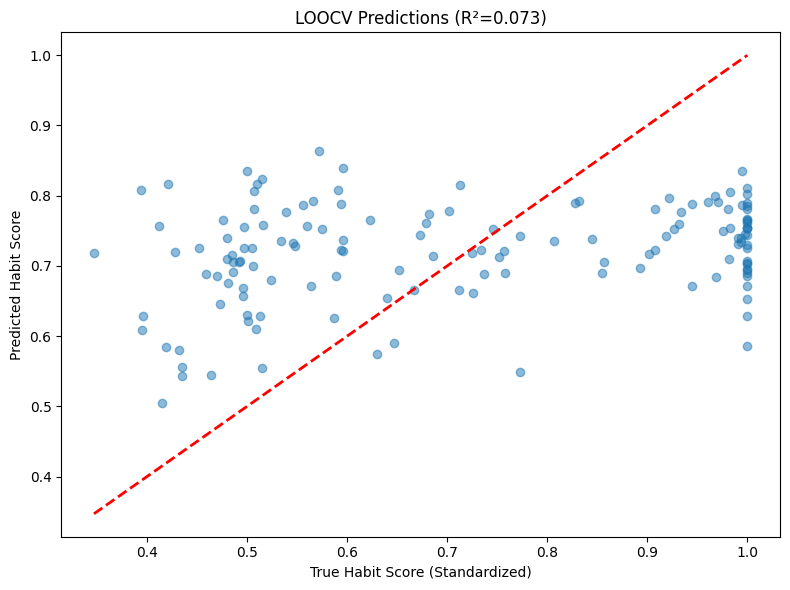


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  SVR_rbf: 144/144 folds (100.0%)

Number of features selected:
  all features: 144/144 folds (100.0%)

Most common configurations:
  SVR_rbf_nfeatall_C0.1_kernelrbf_gamma0.01: 134/144 folds (93.1%)
  SVR_rbf_nfeatall_C1_kernelrbf_gamma0.01: 10/144 folds (6.9%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: SVR_rbf
Number of features: all
Hyperparameters: {'C': 0.1, 'kernel': 'rbf', 'gamma': 0.01}


In [62]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
# merge outcome
block_df = block_df.merge(Dependent_vars[["subID", "devaluation_ratio"]], on="subID", how="inner").reset_index(drop=True)
y = block_df["devaluation_ratio"].astype(float)
subjects = block_df["subID"].reset_index(drop=True)
drop_cols = {"subID", "devaluation_ratio"}
X_cont = block_df.drop(columns=list(drop_cols))
print(f"n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}")

# Convert to arrays
X_cont_arr = X_cont.values
y_arr = np.asarray(y).astype(float)

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
subjects_arr_full = subjects.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}")

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full
subjects = pd.Series(subjects_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")
print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")



# Models to test + # features + settings:
# ----------------------------------------

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
# measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"
# measure_to_pick_model = "mae"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
# n_features_to_test = [3,5,10,'all']
n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, 
                        subjects, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)

                    X_train_Inner = X_cont_train_Inner_pca.copy()
                    X_test_Inner = X_cont_test_Inner_pca.copy()

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mae" and mean_inner_mae < best_inner_score:
                    best_inner_score = mean_inner_mae
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = X_cont_train_Outer_pca.copy()
    X_test_Outer = X_cont_test_Outer_pca.copy()
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "matching_sub": matching_sub,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr,
        subjects,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')



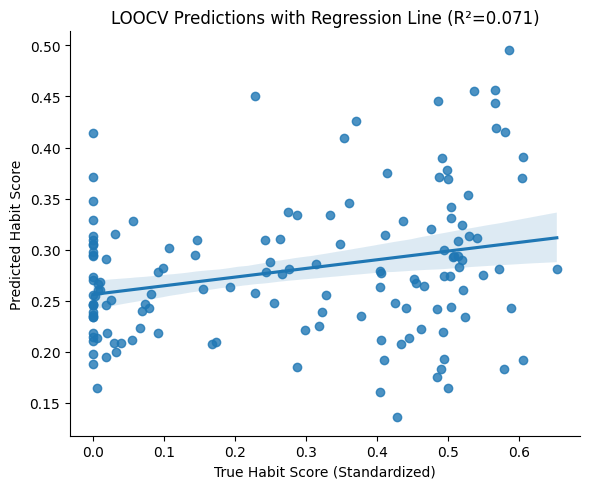

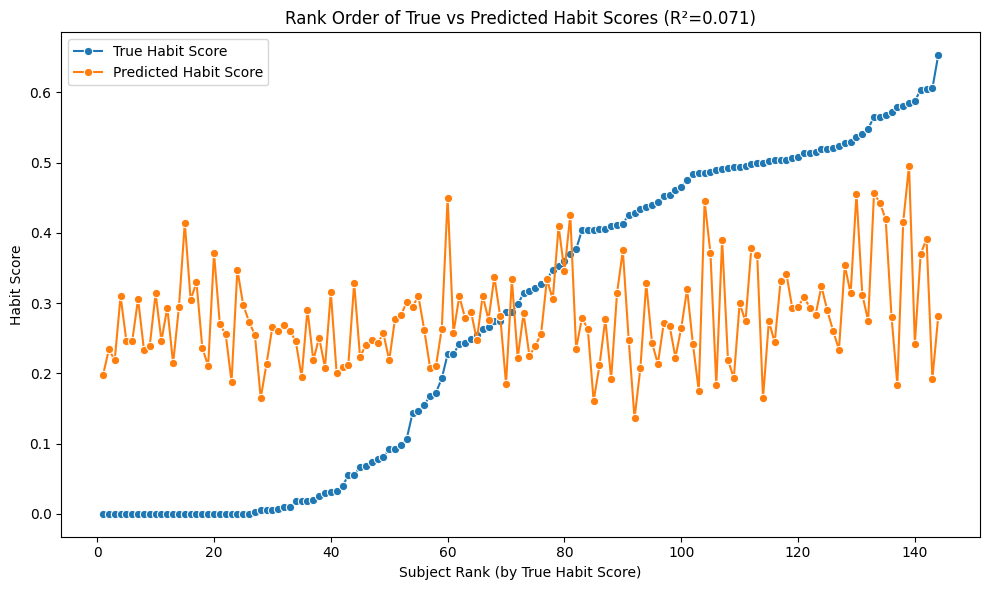

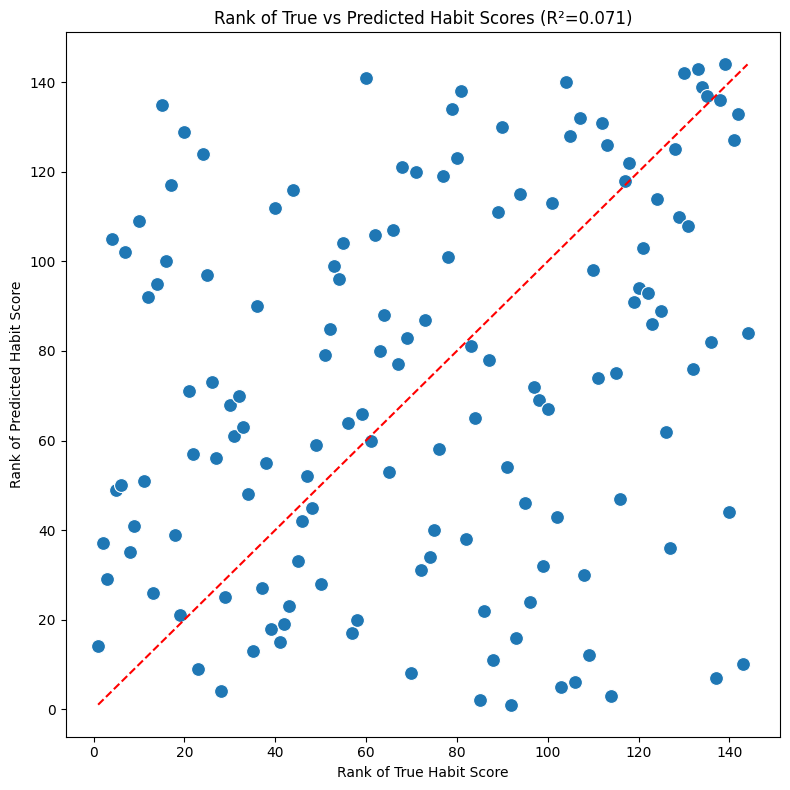

In [37]:
# Now add lmplot:
import seaborn as sns
sns.lmplot(data=pd.DataFrame({'True': y_true_all, 'Predicted': y_pred_all}), x='True', y='Predicted', aspect=1.2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions with Regression Line (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# And rank order plot (i.e. on the x axis the subjects ordered by their true habit score, and on the y axis the ordered predicted habit scores):
# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'True Habit Score': y_true_all,
    'Predicted Habit Score': y_pred_all,
    'Subject': matching_sub_all
})
# Sort by true habit score
plot_df = plot_df.sort_values(by='True Habit Score').reset_index(drop=True)
# Add rank order
plot_df['Rank'] = plot_df.index + 1
# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rank', y='True Habit Score', data=plot_df, marker='o', label='True Habit Score')
sns.lineplot(x='Rank', y='Predicted Habit Score', data=plot_df, marker='o', label='Predicted Habit Score')
plt.xlabel('Subject Rank (by True Habit Score)')
plt.ylabel('Habit Score')
plt.title(f'Rank Order of True vs Predicted Habit Scores (R²={r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# now i want rank of True on the X and rank of Predicted on the Y (so it will be a scatter plot of ranks):
# Create rank columns
plot_df['True Rank'] = plot_df['True Habit Score'].rank(method='first')
plot_df['Predicted Rank'] = plot_df['Predicted Habit Score'].rank(method='first')
# Plot
plt.figure(figsize=(8, 8))
sns.scatterplot(x='True Rank', y='Predicted Rank', data=plot_df, s=100)
plt.plot([1, len(plot_df)], [1, len(plot_df)], 'r--')  # Diagonal line for reference
plt.xlabel('Rank of True Habit Score')
plt.ylabel('Rank of Predicted Habit Score')
plt.title(f'Rank of True vs Predicted Habit Scores (R²={r2:.3f})')
plt.tight_layout()
plt.show()

In [60]:
# ============================================
# PERMUTATION TEST - FULL NESTED LOOCV (PARALLEL)
# - Removes any "group" covariate (no group_arr, no column_stack with group)
# - Runs each permutation as a full nested LOOCV (same logic as your template)
# - Parallelizes ACROSS permutations (each permutation is single-threaded)
# - Prints running p-values every 5 completed permutations
# ============================================

import numpy as np
from itertools import product
from joblib import Parallel, delayed
from tqdm import tqdm

from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# --------------------------------------------
# Settings
# --------------------------------------------
n_permutations = 1000
print_every = 5  # print running p-values every 5 finished permutations

# Observed values from your actual nested CV run
obs_pearson = pearson_r
obs_spearman = spearman_r

# --------------------------------------------
# Single permutation runner (FULL nested LOOCV)
# --------------------------------------------
def _run_single_permutation(
    perm_idx,
    X_cont_arr,
    y_arr,
    models_to_test,
    n_features_to_test,
    n_inner_folds,
    measure_to_pick_model,
    do_PCA,
    pca_var
):
    """
    Run full nested LOOCV on permuted y.
    Returns (perm_idx, pearson_r, spearman_r).
    """
    rng = np.random.RandomState(perm_idx)
    y_perm = rng.permutation(y_arr)

    loo = LeaveOneOut()
    y_true_perm = []
    y_pred_perm = []

    for train_idx, test_idx in loo.split(X_cont_arr):
        X_train = X_cont_arr[train_idx]
        X_test = X_cont_arr[test_idx]
        y_train = y_perm[train_idx]
        y_test = y_perm[test_idx]

        inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)

        best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf
        best_config = None

        # -------------------------
        # Inner loop: pick best config
        # -------------------------
        for model_name, model_dict in models_to_test.items():
            for n_feat in n_features_to_test:
                param_keys = list(model_dict["params"].keys())
                param_values = list(model_dict["params"].values())
                param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)] if param_keys else [{}]

                for params in param_combinations:
                    inner_scores = []

                    for inner_train_idx, inner_test_idx in inner_cv.split(X_train):
                        X_tr_i = X_train[inner_train_idx]
                        X_te_i = X_train[inner_test_idx]
                        y_tr_i = y_train[inner_train_idx]
                        y_te_i = y_train[inner_test_idx]

                        # Scale
                        scaler = StandardScaler().fit(X_tr_i)
                        X_tr_sc = scaler.transform(X_tr_i)
                        X_te_sc = scaler.transform(X_te_i)

                        # PCA
                        if do_PCA:
                            pca = PCA(n_components=pca_var).fit(X_tr_sc)
                            X_tr_pc = pca.transform(X_tr_sc)
                            X_te_pc = pca.transform(X_te_sc)
                        else:
                            X_tr_pc, X_te_pc = X_tr_sc, X_te_sc

                        # Feature selection
                        n_f = X_tr_pc.shape[1]
                        if n_feat != "all" and n_feat < n_f:
                            sel = SelectKBest(f_regression, k=n_feat)
                            X_tr_pc = sel.fit_transform(X_tr_pc, y_tr_i)
                            X_te_pc = sel.transform(X_te_pc)

                        # Fit model
                        if model_name in ["SVR_rbf", "SVR", "Ridge", "Lasso", "ElasticNet", "LinearRegression"]:
                            mdl = model_dict["model"](**params)
                        else:
                            mdl = model_dict["model"](**params, random_state=42)

                        mdl.fit(X_tr_pc, y_tr_i)
                        y_pred_i = mdl.predict(X_te_pc)

                        # Score
                        if measure_to_pick_model == "r2":
                            inner_scores.append(r2_score(y_te_i, y_pred_i))
                        elif measure_to_pick_model == "mae":
                            inner_scores.append(mean_absolute_error(y_te_i, y_pred_i))
                        else:
                            inner_scores.append(mean_squared_error(y_te_i, y_pred_i))

                    mean_score = float(np.mean(inner_scores))

                    if measure_to_pick_model == "r2":
                        is_better = mean_score > best_inner_score
                    else:
                        is_better = mean_score < best_inner_score

                    if is_better:
                        best_inner_score = mean_score
                        best_config = {
                            "model_name": model_name,
                            "model_class": model_dict["model"],
                            "params": params,
                            "n_features": n_feat,
                        }

        # -------------------------
        # Retrain best config on full outer train, predict held-out
        # -------------------------
        scaler = StandardScaler().fit(X_train)
        X_tr_sc = scaler.transform(X_train)
        X_te_sc = scaler.transform(X_test)

        if do_PCA:
            pca = PCA(n_components=pca_var).fit(X_tr_sc)
            X_tr_pc = pca.transform(X_tr_sc)
            X_te_pc = pca.transform(X_te_sc)
        else:
            X_tr_pc, X_te_pc = X_tr_sc, X_te_sc

        n_f = X_tr_pc.shape[1]
        k = best_config["n_features"]
        if k != "all" and k < n_f:
            sel = SelectKBest(f_regression, k=k)
            X_tr_pc = sel.fit_transform(X_tr_pc, y_train)
            X_te_pc = sel.transform(X_te_pc)

        if best_config["model_name"] in ["SVR_rbf", "SVR", "Ridge", "Lasso", "ElasticNet", "LinearRegression"]:
            mdl = best_config["model_class"](**best_config["params"])
        else:
            mdl = best_config["model_class"](**best_config["params"], random_state=42)

        mdl.fit(X_tr_pc, y_train)
        y_true_perm.append(float(y_test[0]))
        y_pred_perm.append(float(mdl.predict(X_te_pc)[0]))

    # Correlations (guard against constant vectors)
    try:
        r_perm, _ = pearsonr(y_true_perm, y_pred_perm)
    except Exception:
        r_perm = np.nan
    try:
        rho_perm, _ = spearmanr(y_true_perm, y_pred_perm)
    except Exception:
        rho_perm = np.nan

    return perm_idx, r_perm, rho_perm


# ============================================
# Parallel execution with running p-value prints
# ============================================

print(f"Running {n_permutations} permutations of FULL nested LOOCV...")
print("This will take a while...")
print(f"Will print running p-values every {print_every} completed permutations.\n")

# We'll collect results as they finish (unordered), and compute running p-values
# in the main process without blocking parallelism.

completed = 0
collected = []

batch_size = 5   # prints every 5 permutations

from joblib import Parallel, delayed
import numpy as np
from tqdm import trange

print(f"Running {n_permutations} permutations of FULL nested LOOCV...")
print(f"Printing running p-values every {batch_size} permutations.\n")

all_results = []

for start in trange(0, n_permutations, batch_size, desc="Permutation batches"):
    end = min(start + batch_size, n_permutations)
    batch_indices = list(range(start, end))

    batch_results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(_run_single_permutation)(
            i,
            X_cont_arr,
            y_arr,
            models_to_test,
            n_features_to_test,
            n_inner_folds,
            measure_to_pick_model,
            do_PCA,
            pca_var,
        )
        for i in batch_indices
    )

    all_results.extend(batch_results)

    # ----------------------------------
    # Compute running p-values
    # ----------------------------------
    tmp = sorted(all_results, key=lambda x: x[0])

    null_pearson = np.array([r[1] for r in tmp], dtype=float)
    null_spearman = np.array([r[2] for r in tmp], dtype=float)

    null_pearson = null_pearson[~np.isnan(null_pearson)]
    null_spearman = null_spearman[~np.isnan(null_spearman)]

    p_pearson = (np.sum(null_pearson >= obs_pearson) + 1) / (len(null_pearson) + 1)
    p_spearman = (np.sum(null_spearman >= obs_spearman) + 1) / (len(null_spearman) + 1)

    print(
        f"[{len(null_pearson):>4}/{n_permutations}] "
        f"running p | Pearson r: {p_pearson:.4f} | Spearman ρ: {p_spearman:.4f}"
    )


null_pearson = np.array([r[1] for r in all_results])
null_spearman = np.array([r[2] for r in all_results])

null_pearson = null_pearson[~np.isnan(null_pearson)]
null_spearman = null_spearman[~np.isnan(null_spearman)]

perm_p_pearson = (np.sum(null_pearson >= obs_pearson) + 1) / (len(null_pearson) + 1)
perm_p_spearman = (np.sum(null_spearman >= obs_spearman) + 1) / (len(null_spearman) + 1)

print(f"\n{'='*60}")
print("PERMUTATION TEST - FULL NESTED LOOCV")
print(f"{'='*60}")
print(f"Pearson r: observed={obs_pearson:.4f}, p_perm={perm_p_pearson:.4f}")
print(f"Spearman ρ: observed={obs_spearman:.4f}, p_perm={perm_p_spearman:.4f}")




Running 1000 permutations of FULL nested LOOCV...
This will take a while...
Will print running p-values every 5 completed permutations.

Running 1000 permutations of FULL nested LOOCV...
Printing running p-values every 5 permutations.



Permutation batches:   0%|          | 1/200 [00:42<2:21:51, 42.77s/it]

[   5/1000] running p | Pearson r: 0.5000 | Spearman ρ: 0.3333


Permutation batches:   1%|          | 2/200 [01:23<2:16:55, 41.49s/it]

[  10/1000] running p | Pearson r: 0.2727 | Spearman ρ: 0.1818


...

[ 990/1000] running p | Pearson r: 0.0353 | Spearman ρ: 0.0262


Permutation batches: 100%|█████████▉| 199/200 [2:15:55<00:42, 42.54s/it]

[ 995/1000] running p | Pearson r: 0.0351 | Spearman ρ: 0.0261


Permutation batches: 100%|██████████| 200/200 [2:16:36<00:00, 40.98s/it]

[1000/1000] running p | Pearson r: 0.0350 | Spearman ρ: 0.0260

PERMUTATION TEST - FULL NESTED LOOCV
Pearson r: observed=0.1626, p_perm=0.0350
Spearman ρ: observed=0.1638, p_perm=0.0260


Just trying other stuff

Repeated CV

n=144, mean=0.723, std=0.220
Total n=144, mean=0.723, std=0.220

RUNNING NESTED CV ON TRAINING SET

n=144, mean=0.723, std=0.219
Outer CV: RepeatedKFold n_splits=10, n_repeats=20, rs=42
Inner CV: KFold n_splits=10, shuffle=True, rs=42
do_PCA=True, pca_var=0.95
n_features_to_test=['all']
measure_to_pick_model=r2
Outer CV folds: 200


Outer CV folds: 100%|██████████| 200/200 [00:07<00:00, 26.18it/s]



NESTED REPEATED 5-FOLD CV REGRESSION RESULTS:
R²: -0.0658
RMSE: 0.2266
MAE: 0.1986
Pearson r: 0.1626 (p=0.0000)
Spearman r: 0.1638 (p=0.0000)


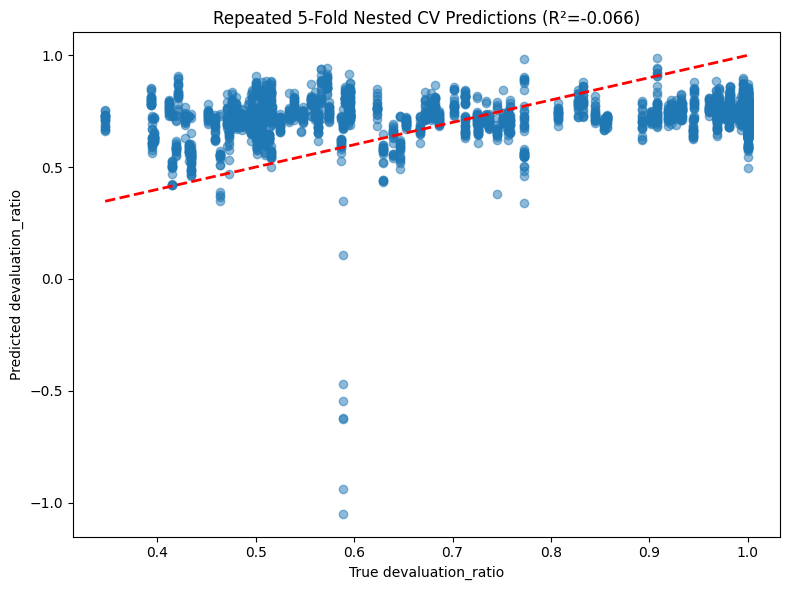


CONFIGURATION SELECTION FREQUENCY:

Model selection frequency:
  SVR_rbf: 174/200 folds (87.0%)
  Lasso: 15/200 folds (7.5%)
  Ridge: 6/200 folds (3.0%)
  ElasticNet: 5/200 folds (2.5%)

Number of features selected:
  all features: 200/200 folds (100.0%)

Most common configurations:
  SVR_rbf_nfeatall_C0.1_kernelrbf_gamma0.01: 118/200 folds (59.0%)
  SVR_rbf_nfeatall_C1_kernelrbf_gamma0.01: 49/200 folds (24.5%)
  Lasso_nfeatall_alpha0.1: 9/200 folds (4.5%)
  SVR_rbf_nfeatall_C0.1_kernelrbf_gammascale: 7/200 folds (3.5%)
  Lasso_nfeatall_alpha1.0: 6/200 folds (3.0%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: SVR_rbf
Number of features: all
Hyperparameters: {'C': 0.1, 'kernel': 'rbf', 'gamma': 0.01}


In [55]:
# ============================================================
# NESTED CV REGRESSION WITH REPEATED 5-FOLD OUTER CV
# (Outer: RepeatedKFold 5 folds x 20 repeats by default)
# (Inner: KFold with n_inner_folds)
# ============================================================

import numpy as np
import pandas as pd

from collections import Counter
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, RepeatedKFold

from sklearn.feature_selection import SelectKBest, f_regression
from scipy.stats import pearsonr, spearmanr

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()

# merge outcome
block_df = block_df.merge(
    Dependent_vars[["subID", "devaluation_ratio"]],
    on="subID",
    how="inner"
).reset_index(drop=True)

y = block_df["devaluation_ratio"].astype(float)
subjects = block_df["subID"].reset_index(drop=True)

drop_cols = {"subID", "devaluation_ratio"}
X_cont = block_df.drop(columns=list(drop_cols))

print(f"n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}")
print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}")

# Convert to arrays
X_cont_arr = X_cont.values
y_arr = np.asarray(y).astype(float)
subjects = pd.Series(subjects.values).reset_index(drop=True)


# ============================================
# SETTINGS
# ============================================

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # Optional
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
}

# Inner CV
n_inner_folds = 10

# PCA
do_PCA = True
pca_var = 0.95

# Model selection metric
# measure_to_pick_model = "mse"
# measure_to_pick_model = "mae"
measure_to_pick_model = "r2"

# Feature selection after PCA
n_features_to_test = ['all']  # or [3, 5, 10, 'all']

# Outer CV: Repeated 5-fold
outer_n_splits = 10
outer_n_repeats = 20
outer_random_state = 42

print(f"\n{'='*60}")
print("RUNNING NESTED CV ON TRAINING SET")
print(f"{'='*60}\n")
print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Outer CV: RepeatedKFold n_splits={outer_n_splits}, n_repeats={outer_n_repeats}, rs={outer_random_state}")
print(f"Inner CV: KFold n_splits={n_inner_folds}, shuffle=True, rs=42")
print(f"do_PCA={do_PCA}, pca_var={pca_var}")
print(f"n_features_to_test={n_features_to_test}")
print(f"measure_to_pick_model={measure_to_pick_model}")


def _score_is_better(new_score: float, best_score: float, measure: str) -> bool:
    # r2: higher is better
    if measure == "r2":
        return new_score > best_score
    # mse/mae: lower is better
    return new_score < best_score


def _init_best_score(measure: str) -> float:
    return -np.inf if measure == "r2" else np.inf


def _compute_inner_score(y_true, y_pred, measure: str) -> float:
    if measure == "r2":
        return r2_score(y_true, y_pred)
    if measure == "mae":
        return mean_absolute_error(y_true, y_pred)
    # default mse
    return mean_squared_error(y_true, y_pred)


def _process_outer_fold(
    fold_idx,
    train_index,
    test_index,
    X_cont_arr,
    y_arr,
    subjects,
    models_to_test,
    n_features_to_test,
    n_inner_folds,
    measure_to_pick_model,
    do_PCA,
    pca_var,
):
    configs_data_fold = {}

    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]

    matching_sub = subjects.iloc[test_index].tolist()

    # Inner CV (regression)
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)

    best_inner_score = _init_best_score(measure_to_pick_model)
    best_config = None

    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())

            if len(param_keys) == 0:
                param_combinations = [dict()]
            else:
                param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]

            for params in param_combinations:
                inner_scores = []
                inner_r2 = []
                inner_mse = []
                inner_mae = []

                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_tr_sc = scaler.transform(X_cont_train_Inner)
                    X_te_sc = scaler.transform(X_cont_test_Inner)

                    # PCA (fit on Inner TRAIN only)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_tr_sc)
                        X_tr_pc = pca.transform(X_tr_sc)
                        X_te_pc = pca.transform(X_te_sc)
                    else:
                        X_tr_pc, X_te_pc = X_tr_sc, X_te_sc

                    # Feature selection (after PCA)
                    n_features = X_tr_pc.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_tr_pc = selector.fit_transform(X_tr_pc, y_train_Inner)
                        X_te_pc = selector.transform(X_te_pc)

                    X_train_Inner = X_tr_pc
                    X_test_Inner = X_te_pc

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression', 'Ridge', 'Lasso', 'ElasticNet']:
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)

                    # Predict and score
                    y_pred_Inner = model.predict(X_test_Inner)

                    inner_r2.append(r2_score(y_test_Inner, y_pred_Inner))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_pred_Inner))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_pred_Inner))
                    inner_scores.append(_compute_inner_score(y_test_Inner, y_pred_Inner, measure_to_pick_model))

                mean_inner_score = float(np.mean(inner_scores))
                mean_inner_r2 = float(np.mean(inner_r2))
                mean_inner_mse = float(np.mean(inner_mse))
                mean_inner_mae = float(np.mean(inner_mae))

                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_score': mean_inner_score,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae,
                }

                # Pick best config
                if _score_is_better(mean_inner_score, best_inner_score, measure_to_pick_model):
                    best_inner_score = mean_inner_score
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_score': mean_inner_score,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae,
                    }

    # Retrain best config on full OUTER train
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_tr_sc = scaler.transform(X_cont_train_Outer)
    X_te_sc = scaler.transform(X_cont_test_Outer)

    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_tr_sc)
        X_tr_pc = pca.transform(X_tr_sc)
        X_te_pc = pca.transform(X_te_sc)
    else:
        X_tr_pc, X_te_pc = X_tr_sc, X_te_sc

    n_features_outer = X_tr_pc.shape[1]
    k_final = best_config["n_features"]
    if k_final != "all" and k_final < n_features_outer:
        selector_final = SelectKBest(f_regression, k=k_final)
        X_tr_pc = selector_final.fit_transform(X_tr_pc, y_train_Outer)
        X_te_pc = selector_final.transform(X_te_pc)

    X_train_Outer = X_tr_pc
    X_test_Outer = X_te_pc

    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression', 'Ridge', 'Lasso', 'ElasticNet']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    y_true = y_test_Outer.copy()
    y_pred = model_final.predict(X_test_Outer).copy()

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "matching_sub": matching_sub,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }


# ============================================
# OUTER CV SPLITS (Repeated 5-fold)
# ============================================
outer_cv = RepeatedKFold(
    n_splits=outer_n_splits,
    n_repeats=outer_n_repeats,
    random_state=outer_random_state
)
outer_splits = list(outer_cv.split(X_cont_arr))
print(f"Outer CV folds: {len(outer_splits)}")

# ============================================
# RUN NESTED CV
# ============================================
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr,
        subjects,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model,
        do_PCA, pca_var
    )
    for fold_idx, (train_index, test_index) in tqdm(
        list(enumerate(outer_splits)),
        total=len(outer_splits),
        desc="Outer CV folds"
    )
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

# Concatenate predictions across folds (since each fold has multiple test samples)
y_true_all = np.concatenate([np.asarray(r["y_true"], dtype=float) for r in results])
y_pred_all = np.concatenate([np.asarray(r["y_pred"], dtype=float) for r in results])
matching_sub_all = sum([r["matching_sub"] for r in results], [])

selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = float(np.sqrt(mse))

pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED REPEATED 5-FOLD CV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')

# ============================================
# PLOT PREDICTIONS VS ACTUAL
# ============================================
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot(
    [y_true_all.min(), y_true_all.max()],
    [y_true_all.min(), y_true_all.max()],
    'r--', lw=2
)
plt.xlabel('True devaluation_ratio')
plt.ylabel('Predicted devaluation_ratio')
plt.title(f'Repeated 5-Fold Nested CV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================
print(f'\n{"="*60}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'{"="*60}')

model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

print(f'\nMost common configurations:')
config_strings = [
    f"{c['model_name']}_nfeat{c['n_features']}_" +
    "_".join([f"{k}{v}" for k, v in c['params'].items()
              if k not in ['probability', 'solver', 'max_iter', 'random_state']])
    for c in selected_configs
]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# "BEST" CONFIGURATION FOR DEPLOYMENT
# (Most frequently selected model + n_features + most common params within that model)
# ============================================
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

if len(configs_for_model) > 0:
    for key in configs_for_model[0]['params'].keys():
        param_values = [c['params'][key] for c in configs_for_model]
        best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')



Per-subject evaluation (aggregated predictions):
n_subjects: 144
R2: 0.0222
RMSE: 0.2170
MAE: 0.1958
Pearson r: 0.2109 (p=0.01117)
Spearman rho: 0.2040 (p=0.0142)


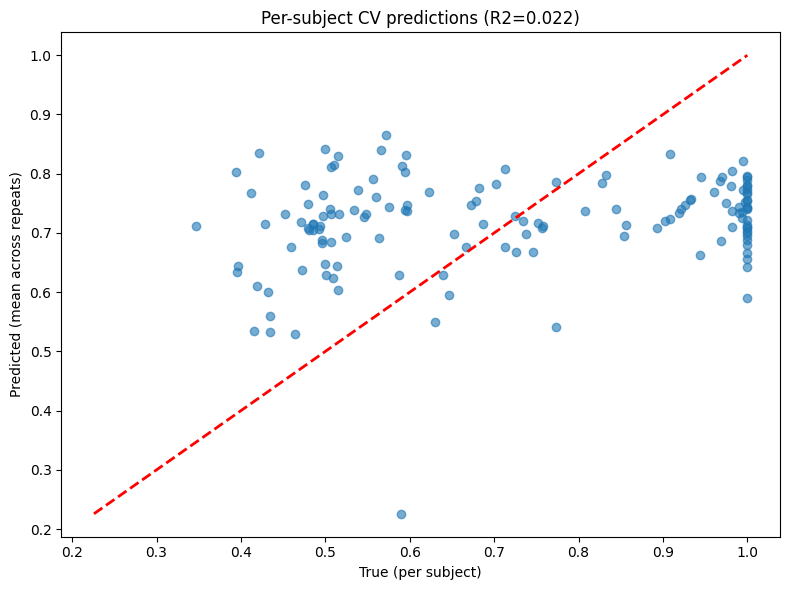

In [56]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

def evaluate_per_subject(y_true_all, y_pred_all, sub_all, agg_pred="mean"):
    """
    Collapse to one prediction per subject, then compute metrics.
    agg_pred: "mean" or "median"
    """
    df = pd.DataFrame({
        "sub": np.asarray(sub_all),
        "y_true": np.asarray(y_true_all, dtype=float),
        "y_pred": np.asarray(y_pred_all, dtype=float),
    })

    # Sanity: y_true should be constant within subject. Keep the first, and warn if not.
    true_nuniq = df.groupby("sub")["y_true"].nunique()
    bad = true_nuniq[true_nuniq > 1]
    if len(bad) > 0:
        print(f"WARNING: {len(bad)} subjects have >1 unique y_true across folds. Examples:")
        print(bad.head())

    if agg_pred == "median":
        df_sub = df.groupby("sub", as_index=False).agg(
            y_true=("y_true", "first"),
            y_pred=("y_pred", "median"),
            n_preds=("y_pred", "size"),
            pred_std=("y_pred", "std"),
        )
    else:
        df_sub = df.groupby("sub", as_index=False).agg(
            y_true=("y_true", "first"),
            y_pred=("y_pred", "mean"),
            n_preds=("y_pred", "size"),
            pred_std=("y_pred", "std"),
        )

    y_t = df_sub["y_true"].to_numpy()
    y_p = df_sub["y_pred"].to_numpy()

    r2 = r2_score(y_t, y_p)
    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    pr, pp = pearsonr(y_t, y_p)
    sr, sp = spearmanr(y_t, y_p)

    out = {
        "n_subjects": len(df_sub),
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pr,
        "pearson_p": pp,
        "spearman_rho": sr,
        "spearman_p": sp,
        "df_subject": df_sub,
    }
    return out

# Example usage after CV:
# y_true_all: shape (n_predictions_total,)
# y_pred_all: shape (n_predictions_total,)
# matching_sub_all: same length, subject id per prediction

res = evaluate_per_subject(y_true_all, y_pred_all, matching_sub_all, agg_pred="mean")

print("\nPer-subject evaluation (aggregated predictions):")
print(f"n_subjects: {res['n_subjects']}")
print(f"R2: {res['r2']:.4f}")
print(f"RMSE: {res['rmse']:.4f}")
print(f"MAE: {res['mae']:.4f}")
print(f"Pearson r: {res['pearson_r']:.4f} (p={res['pearson_p']:.4g})")
print(f"Spearman rho: {res['spearman_rho']:.4f} (p={res['spearman_p']:.4g})")

# Optional plot (per subject)
import matplotlib.pyplot as plt
df_sub = res["df_subject"]

plt.figure(figsize=(8, 6))
plt.scatter(df_sub["y_true"], df_sub["y_pred"], alpha=0.6)
mn = min(df_sub["y_true"].min(), df_sub["y_pred"].min())
mx = max(df_sub["y_true"].max(), df_sub["y_pred"].max())
plt.plot([mn, mx], [mn, mx], "r--", lw=2)
plt.xlabel("True (per subject)")
plt.ylabel("Predicted (mean across repeats)")
plt.title(f"Per-subject CV predictions (R2={res['r2']:.3f})")
plt.tight_layout()
plt.show()


Hurdle....:

n=144, mean=0.723, std=0.219
Ceiling y==1 count: 26/144 (0.181)


Outer LOOCV folds:   0%|          | 0/144 [00:00<?, ?it/s]

Outer LOOCV folds: 100%|██████████| 144/144 [02:26<00:00,  1.02s/it]



HURDLE NESTED LOOCV RESULTS
Overall regression:
  R²: -0.0005
  RMSE: 0.2195
  MAE: 0.1909
  Pearson r: 0.2796 (p=0.0007)
  Spearman ρ: 0.2748 (p=0.0009)

Ceiling (y==1) classification:
  AUROC: 0.2885
  AUPRC: 0.1262
  Balanced Acc @0.5: 0.5000

Most common configs (top 5):
  50/144: nfeat=all,clf=SVC_rbf,reg=Ridge,thr=0.3,C=0.1,gamma=scale,kernel=rbf,probability=True|alpha=10.0
  20/144: nfeat=all,clf=SVC_rbf,reg=Ridge,thr=0.3,C=10,gamma=scale,kernel=rbf,probability=True|alpha=10.0
  19/144: nfeat=all,clf=SVC_rbf,reg=ElasticNet,thr=0.3,C=0.1,gamma=scale,kernel=rbf,probability=True|alpha=0.1,l1_ratio=0.5,max_iter=5000
  18/144: nfeat=all,clf=SVC_rbf,reg=Ridge,thr=0.3,C=0.1,gamma=0.01,kernel=rbf,probability=True|alpha=10.0
  11/144: nfeat=all,clf=SVC_rbf,reg=Ridge,thr=0.3,C=1,gamma=scale,kernel=rbf,probability=True|alpha=10.0


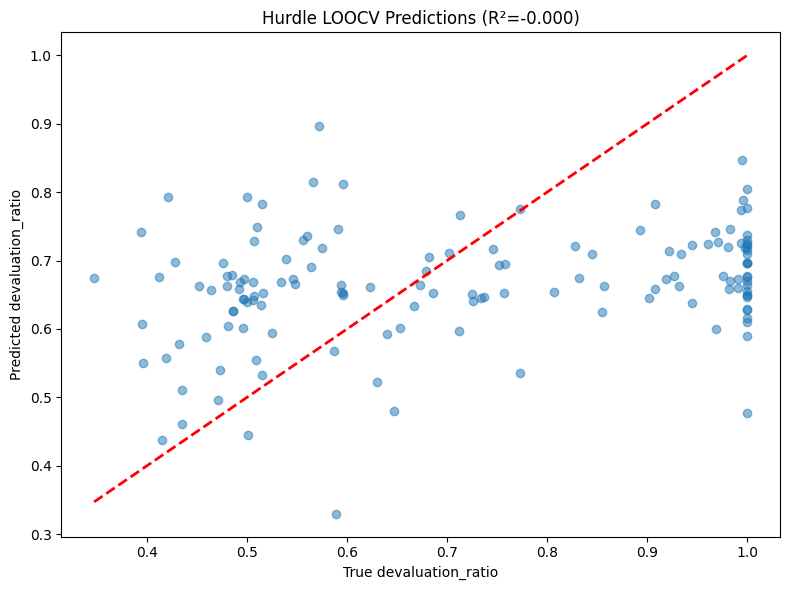

In [41]:
# ============================================================
# HURDLE MODEL: y==1 (ceiling) classification + y<1 regression
# Nested LOOCV outer loop, nested KFold inner loop
# Keeps your PCA/SelectKBest structure (optional)
# ============================================================

import numpy as np
import pandas as pd
from collections import Counter
from itertools import product
from joblib import Parallel, delayed
from tqdm import tqdm

from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, average_precision_score, balanced_accuracy_score
)
from scipy.stats import pearsonr, spearmanr


# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
block_df = block_df.merge(
    Dependent_vars[["subID", "devaluation_ratio"]],
    on="subID", how="inner"
).reset_index(drop=True)

y = block_df["devaluation_ratio"].astype(float).values
subjects = block_df["subID"].reset_index(drop=True)

drop_cols = {"subID", "devaluation_ratio"}
X_cont = block_df.drop(columns=list(drop_cols)).values

print(f"n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}")

# Define the structural ceiling
ONE_THR = 1.0  # if float noise exists: 0.999999
is_one = (y >= ONE_THR).astype(int)
print(f"Ceiling y==1 count: {is_one.sum()}/{len(is_one)} ({is_one.mean():.3f})")


# ============================================
# MODEL GRIDS
# ============================================

# Classifier for y==1
clf_models = {
    "LogReg": {
        "model": LogisticRegression,
        "params": {
            "C": [0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["liblinear"],
            "max_iter": [5000]
        }
    },
    "SVC_rbf": {
        "model": SVC,
        "params": {
            "C": [0.1, 1, 10],
            "gamma": ["scale", 0.01, 0.1],
            "kernel": ["rbf"],
            "probability": [True]
        }
    },
}

# Regressor for y<1
reg_models = {
    "Ridge": {"model": Ridge, "params": {"alpha": [0.1, 1.0, 10.0]}},
    "Lasso": {"model": Lasso, "params": {"alpha": [0.1, 1.0, 10.0], "max_iter": [5000]}},
    "ElasticNet": {"model": ElasticNet, "params": {"alpha": [0.1, 1.0, 10.0], "l1_ratio": [0.5], "max_iter": [5000]}},
    "SVR_rbf": {"model": SVR, "params": {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1], "kernel": ["rbf"]}},
    # "RandomForest": {"model": RandomForestRegressor, "params": {"max_depth": [5, 10], "min_samples_leaf": [5, 10]}},
}

# Feature pipeline choices
do_PCA = True
pca_var = 0.95
n_features_to_test = ["all"]  # or [3,5,10,"all"]
n_inner_folds = 10

# Threshold grid for ceiling decision
thr_grid = [0.3, 0.4, 0.5, 0.6, 0.7]
thr_grid = [0.3]

# Choose objective for selecting hurdle configuration in inner CV
# We recommend minimizing MSE on the FULL outcome after combining heads
pick_metric = "mse"  # "mse" or "mae"


# ============================================
# Helpers
# ============================================
def _fit_transform_pipeline(X_tr, X_te, y_tr_reg, do_PCA, pca_var, n_feat):
    """Scale -> (optional PCA) -> (optional SelectKBest) fit on TRAIN only."""
    scaler = StandardScaler().fit(X_tr)
    X_tr_sc = scaler.transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_tr_sc)
        X_tr_z = pca.transform(X_tr_sc)
        X_te_z = pca.transform(X_te_sc)
    else:
        X_tr_z, X_te_z = X_tr_sc, X_te_sc

    n_f = X_tr_z.shape[1]
    selector = None
    if n_feat != "all" and n_feat < n_f:
        selector = SelectKBest(f_regression, k=n_feat)
        X_tr_z = selector.fit_transform(X_tr_z, y_tr_reg)
        X_te_z = selector.transform(X_te_z)

    return X_tr_z, X_te_z, scaler, (pca if do_PCA else None), selector


def _build_param_grid(model_dict):
    keys = list(model_dict["params"].keys())
    if len(keys) == 0:
        return [{}]
    values = list(model_dict["params"].values())
    return [dict(zip(keys, v)) for v in product(*values)]


def _predict_proba_clf(clf, X):
    """Return P(y==1). Works for LogReg and probability=True SVC."""
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    # fallback (shouldn't happen here)
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        # map to (0,1) via logistic
        return 1 / (1 + np.exp(-s))
    raise RuntimeError("Classifier has neither predict_proba nor decision_function.")


# ============================================
# Outer fold worker
# ============================================
def _process_outer_fold_hurdle(fold_idx, train_idx, test_idx, X, y, is_one,
                               clf_models, reg_models, n_features_to_test,
                               n_inner_folds, do_PCA, pca_var, thr_grid, pick_metric):

    X_tr_full, X_te_full = X[train_idx], X[test_idx]
    y_tr_full, y_te = y[train_idx], y[test_idx][0]
    is_one_tr, is_one_te = is_one[train_idx], is_one[test_idx][0]

    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)

    best_score = np.inf
    best_cfg = None

    # Inner CV over full TRAIN set, selecting best (clf, reg, n_feat, params, thr)
    for n_feat in n_features_to_test:

        # For regression head we fit only on non-ceiling points in each inner fold,
        # but the transform must be fit on all X_tr_i (to avoid "peeking" at y via filtering)
        for clf_name, clf_dict in clf_models.items():
            for clf_params in _build_param_grid(clf_dict):

                for reg_name, reg_dict in reg_models.items():
                    for reg_params in _build_param_grid(reg_dict):

                        for thr in thr_grid:
                            fold_losses = []

                            for inner_tr_i, inner_te_i in inner_cv.split(X_tr_full):
                                X_tr_i, X_te_i = X_tr_full[inner_tr_i], X_tr_full[inner_te_i]
                                y_tr_i, y_te_i = y_tr_full[inner_tr_i], y_tr_full[inner_te_i]
                                is_one_tr_i, is_one_te_i = is_one_tr[inner_tr_i], is_one_tr[inner_te_i]

                                # Pipeline fit on inner TRAIN only
                                # For SelectKBest we need y values. Use regression y among non-ones,
                                # but if too few non-ones exist, skip feature selection by forcing "all".
                                y_tr_reg_i = y_tr_i[is_one_tr_i == 0]
                                n_feat_eff = n_feat
                                if (n_feat != "all") and (len(y_tr_reg_i) < 5):
                                    n_feat_eff = "all"

                                X_tr_z, X_te_z, _, _, _ = _fit_transform_pipeline(
                                    X_tr_i, X_te_i,
                                    y_tr_reg_i if len(y_tr_reg_i) > 0 else y_tr_i,
                                    do_PCA, pca_var, n_feat_eff
                                )

                                # Fit classifier on all inner TRAIN
                                clf = clf_dict["model"](**clf_params)
                                clf.fit(X_tr_z, is_one_tr_i)
                                p_one = _predict_proba_clf(clf, X_te_z)

                                # Fit regressor on non-ones only
                                mask_reg = (is_one_tr_i == 0)
                                if mask_reg.sum() < 5:
                                    # not enough data: fallback to predicting mean of non-ones (or mean overall)
                                    y_hat_reg = np.full(shape=len(X_te_z), fill_value=float(np.mean(y_tr_i)))
                                else:
                                    reg = reg_dict["model"](**reg_params)
                                    reg.fit(X_tr_z[mask_reg], y_tr_i[mask_reg])
                                    y_hat_reg = reg.predict(X_te_z)

                                # Combine hurdle prediction
                                y_hat = np.where(p_one >= thr, 1.0, y_hat_reg)

                                # Enforce bounds [0.33, 1] and keep non-ceiling strictly <1 when not classified as one
                                y_hat = np.clip(y_hat, 0.33, 1.0)

                                # Loss on inner TEST
                                if pick_metric == "mae":
                                    loss = mean_absolute_error(y_te_i, y_hat)
                                else:
                                    loss = mean_squared_error(y_te_i, y_hat)
                                fold_losses.append(loss)

                            mean_loss = float(np.mean(fold_losses))
                            if mean_loss < best_score:
                                best_score = mean_loss
                                best_cfg = dict(
                                    n_feat=n_feat,
                                    clf_name=clf_name, clf_class=clf_dict["model"], clf_params=clf_params,
                                    reg_name=reg_name, reg_class=reg_dict["model"], reg_params=reg_params,
                                    thr=thr,
                                    inner_loss=mean_loss
                                )

    # Refit best config on full OUTER TRAIN, predict OUTER TEST
    # Fit transform on full outer train (use non-one y for selector if possible)
    y_tr_reg = y_tr_full[is_one_tr == 0]
    n_feat_eff = best_cfg["n_feat"]
    if (n_feat_eff != "all") and (len(y_tr_reg) < 5):
        n_feat_eff = "all"

    X_tr_z, X_te_z, _, _, _ = _fit_transform_pipeline(
        X_tr_full, X_te_full,
        y_tr_reg if len(y_tr_reg) > 0 else y_tr_full,
        do_PCA, pca_var, n_feat_eff
    )

    # Fit classifier on all outer train
    clf_final = best_cfg["clf_class"](**best_cfg["clf_params"])
    clf_final.fit(X_tr_z, is_one_tr)
    p_one_te = float(_predict_proba_clf(clf_final, X_te_z)[0])

    # Fit regressor on non-ones
    mask_reg = (is_one_tr == 0)
    if mask_reg.sum() < 5:
        y_hat_reg_te = float(np.mean(y_tr_full))
    else:
        reg_final = best_cfg["reg_class"](**best_cfg["reg_params"])
        reg_final.fit(X_tr_z[mask_reg], y_tr_full[mask_reg])
        y_hat_reg_te = float(reg_final.predict(X_te_z)[0])

    y_pred_te = 1.0 if p_one_te >= best_cfg["thr"] else y_hat_reg_te
    y_pred_te = float(np.clip(y_pred_te, 0.33, 1.0))

    return dict(
        fold_idx=fold_idx,
        y_true=y_te,
        y_pred=y_pred_te,
        is_one_true=int(is_one_te),
        p_one=p_one_te,
        best_cfg=best_cfg
    )


# ============================================
# RUN OUTER LOOCV (can parallelize across folds)
# ============================================
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont))

results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold_hurdle)(
        fold_idx, tr, te,
        X_cont, y, is_one,
        clf_models, reg_models,
        n_features_to_test,
        n_inner_folds, do_PCA, pca_var, thr_grid, pick_metric
    )
    for fold_idx, (tr, te) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer LOOCV folds")
)

results = sorted(results, key=lambda d: d["fold_idx"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
is_one_true_all = np.array([r["is_one_true"] for r in results], dtype=int)
p_one_all = np.array([r["p_one"] for r in results], dtype=float)
selected_cfgs = [r["best_cfg"] for r in results]


# ============================================
# METRICS: regression (overall) + ceiling classification
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = float(np.sqrt(mse))
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

# Classification metrics for ceiling event
# Use p_one as score; use threshold 0.5 only for balanced accuracy (you can also use fold-specific thr)
try:
    auroc = roc_auc_score(is_one_true_all, p_one_all)
except ValueError:
    auroc = np.nan
try:
    auprc = average_precision_score(is_one_true_all, p_one_all)
except ValueError:
    auprc = np.nan

# For a single hard threshold, use 0.5 (or use the per-fold best_cfg["thr"] if you want)
y_one_hat_05 = (p_one_all >= 0.5).astype(int)
bal_acc = balanced_accuracy_score(is_one_true_all, y_one_hat_05)

print("\n" + "="*60)
print("HURDLE NESTED LOOCV RESULTS")
print("="*60)
print(f"Overall regression:")
print(f"  R²: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})")
print(f"  Spearman ρ: {spearman_r:.4f} (p={spearman_p:.4f})")
print(f"\nCeiling (y==1) classification:")
print(f"  AUROC: {auroc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  Balanced Acc @0.5: {bal_acc:.4f}")

# Config stability
cfg_strings = [
    f"nfeat={c['n_feat']},clf={c['clf_name']},reg={c['reg_name']},thr={c['thr']},"
    + ",".join([f"{k}={v}" for k, v in c["clf_params"].items()])
    + "|"
    + ",".join([f"{k}={v}" for k, v in c["reg_params"].items()])
    for c in selected_cfgs
]
cfg_counts = Counter(cfg_strings)
print("\nMost common configs (top 5):")
for cfg, cnt in cfg_counts.most_common(5):
    print(f"  {cnt}/{len(cfg_strings)}: {cfg}")

# Optional plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()],
         [y_true_all.min(), y_true_all.max()], "r--", lw=2)
plt.xlabel("True devaluation_ratio")
plt.ylabel("Predicted devaluation_ratio")
plt.title(f"Hurdle LOOCV Predictions (R²={r2:.3f})")
plt.tight_layout()
plt.show()


In [ ]:
============================================================
CONFIGURATION SELECTION FREQUENCY:

============================================================

Model selection frequency:
  SVR_rbf: 140/144 folds (97.2%)
  RandomForest: 4/144 folds (2.8%)

Number of features selected:
  10 features: 84/144 folds (58.3%)
  5 features: 55/144 folds (38.2%)
  3 features: 5/144 folds (3.5%)

Most common configurations:
  SVR_rbf_nfeat10_C0.1_kernelrbf_gamma0.01: 80/144 folds (55.6%)
  SVR_rbf_nfeat5_C0.1_kernelrbf_gamma0.01: 39/144 folds (27.1%)
  SVR_rbf_nfeat5_C1_kernelrbf_gamma0.01: 15/144 folds (10.4%)
  SVR_rbf_nfeat3_C1_kernelrbf_gamma0.01: 3/144 folds (2.1%)
  SVR_rbf_nfeat3_C0.1_kernelrbf_gamma0.01: 2/144 folds (1.4%)

============================================================
RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
============================================================
Model: SVR_rbf
Number of features: 10
Hyperparameters: {'C': 0.1, 'kernel': 'rbf', 'gamma': 0.01}



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0537
RMSE: 0.2135
MAE: 0.1919
Pearson r: 0.2450 (p=0.0031)
Spearman r: 0.2331 (p=0.0049)


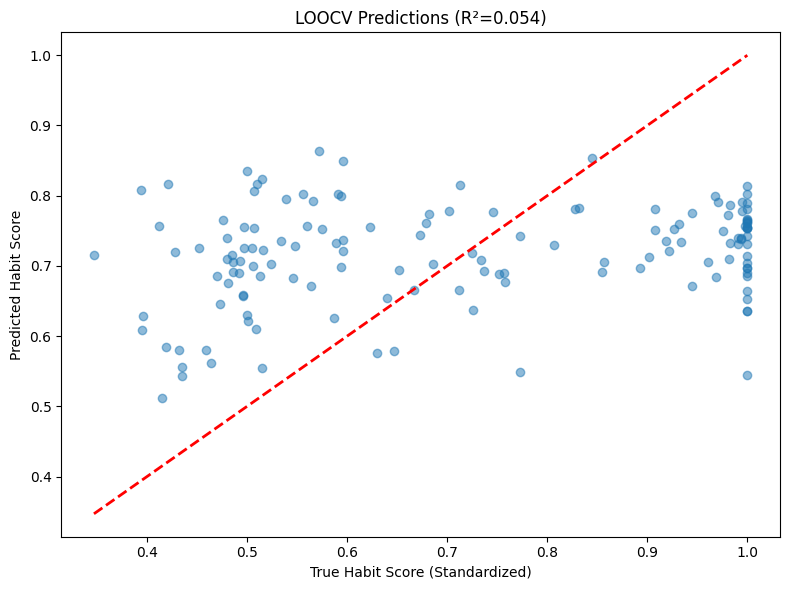

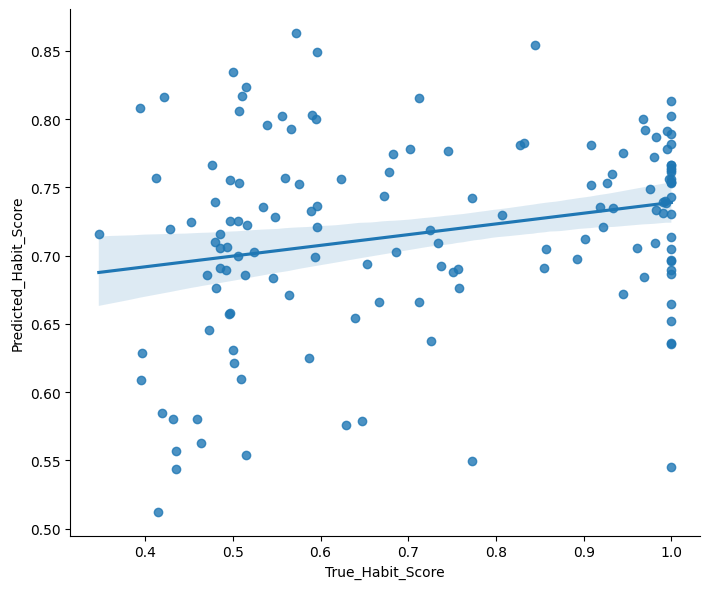

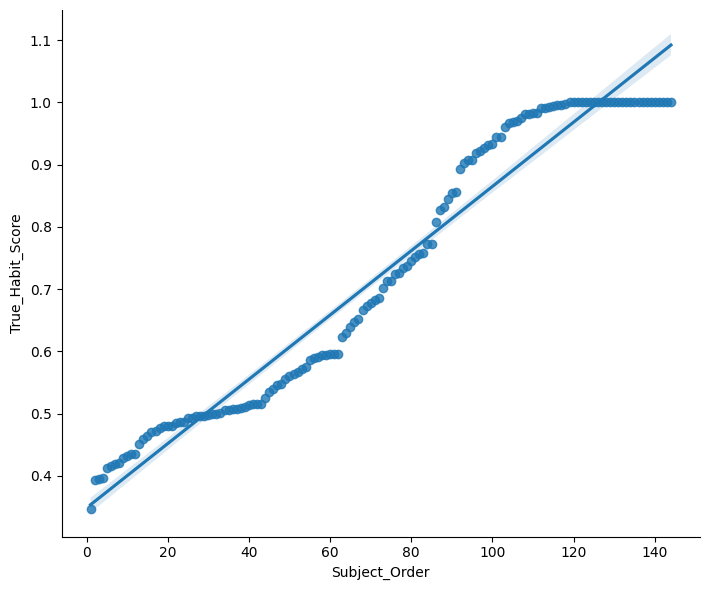

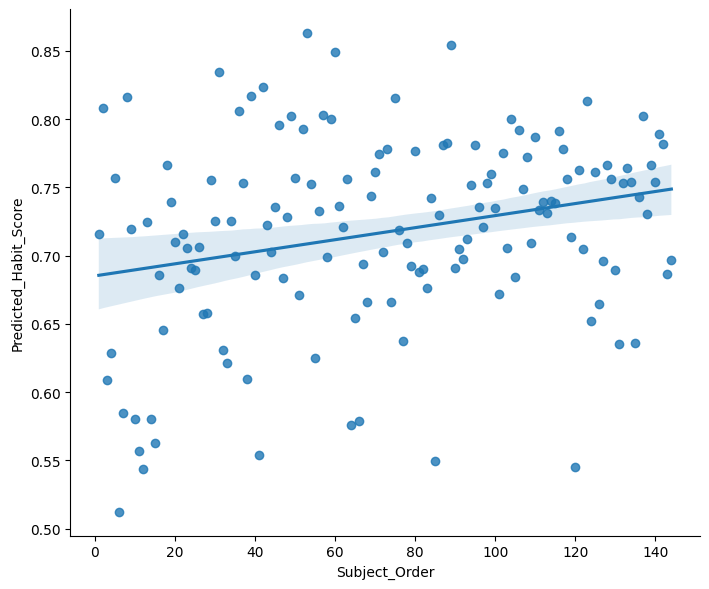

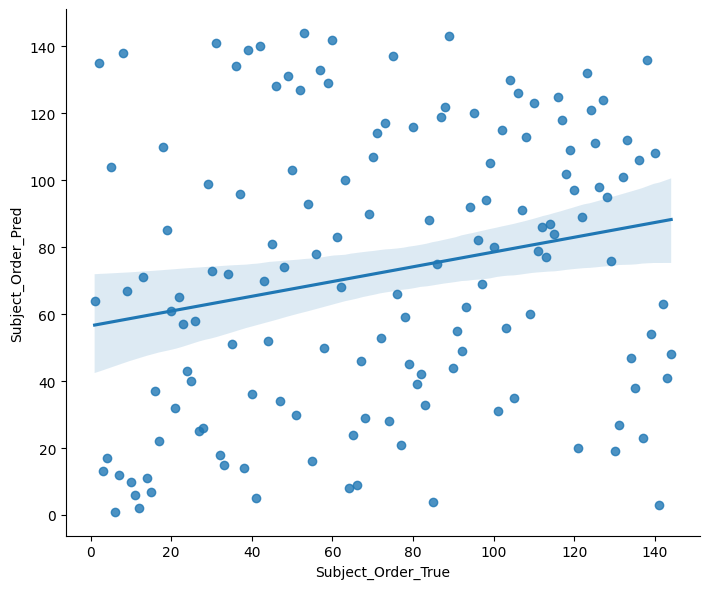

In [33]:
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# now lmplot:
import seaborn as sns
import pandas as pd
df_plot = pd.DataFrame({
    'True_Habit_Score': y_true_all,
    'Predicted_Habit_Score': y_pred_all
})
sns.lmplot(x='True_Habit_Score', y='Predicted_Habit_Score', data=df_plot, height=6, aspect=1.2)

# Now I want a Spearmn matching scatter plot (i.. by order):
df_plot = pd.DataFrame({
    'Subject': matching_sub_all,
    'True_Habit_Score': y_true_all,
    'Predicted_Habit_Score': y_pred_all
})
df_plot = df_plot.sort_values(by='True_Habit_Score').reset_index(drop=True)
df_plot['Subject_Order'] = df_plot.index + 1  # 1-based index
sns.lmplot(x='Subject_Order', y='True_Habit_Score', data=df_plot, height=6, aspect=1.2)
sns.lmplot(x='Subject_Order', y='Predicted_Habit_Score', data=df_plot, height=6, aspect=1.2)
# Now order by true vs. predicted:
df_plot_true_sorted = df_plot.sort_values(by='True_Habit_Score').reset_index(drop=True)
df_plot_pred_sorted = df_plot.sort_values(by='Predicted_Habit_Score').reset_index(drop=True)
df_plot_true_sorted['Subject_Order_True'] = df_plot_true_sorted.index + 1  # 1-based index
df_plot_pred_sorted['Subject_Order_Pred'] = df_plot_pred_sorted.index + 1  # 1-based index
sns.lmplot(x='Subject_Order_True', y='Subject_Order_Pred', data=pd.merge(df_plot_true_sorted, df_plot_pred_sorted, on='Subject'), height=6, aspect=1.2)


## Significance tests

### Simulations

In [277]:
# Permutation test (LOOCV)
n_permutations = 1000
model = SVC()
loo = LeaveOneOut()

# for block_to_extract in all_pre_deval_blocks:
    # block_data = pca_df[pca_df['block']==block_to_extract].reset_index(drop=True)
    # for type_ in ['short', 'long', 'all']:
for type_ in ['all']:
    # if block_to_extract not in pre_deval_blocks[type_]:
    #     continue
    print(f'-------------------------------------------------------------------------------')
    print(f'Running permutations: model: {model} || group: {type_}')
    block_data, _, _, _ = get_PCA_data_R01(features_data, Dependent_vars, group=type_, n_components=0.95)
    X = block_data.loc[:,'group':]
    y = (block_data.devaluation_ratio_binary).astype(int)

    permuted_accuracies = []
    for i in range(n_permutations):
        if i % 50 == 0:
            print(f'Permutation {i+1}/{n_permutations}')
        y_permuted = np.random.permutation(y)  # Shuffle the target labels
        # Lists to store actual and predicted values
        y_true_perm = []
        y_pred = []
        # Perform Leave-One-Out Cross-Validation
        for train_index, test_index in loo.split(X):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y_permuted[train_index], y_permuted[test_index]
            
            # Train the model
            model.fit(X_train, y_train)
            
            # Make prediction
            y_test_pred = model.predict(X_test)
            # y_test_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability for the positive class
            
            # Store actual and predicted values
            y_true_perm.append(y_test[0])
            y_pred.append(y_test_pred[0])

        # Convert lists to numpy arrays
        y_true_perm = np.array(y_true_perm)
        y_pred = np.array(y_pred)
        # y_pred_proba = np.array(y_pred_proba)

        # Evaluate the model
        perm_acc = accuracy_score(y_true_perm, y_pred)
        permuted_accuracies.append(perm_acc)
        
    # Calc and Output results
    acc = LOOCV_SVC_results[type_]['run1']['accuracy']
    p_value = np.mean([1 if perm_acc >= acc else 0 for perm_acc in permuted_accuracies])
    print(f'Majority class (which is {y.mode().values[0]}) proportion: {y.mean()}.')
    print(f'Real Data Accuracy (LOOCV): {acc:.4f}')
    print(f'P-value from Permutation Test: {p_value:.4f}')
    print(f'-------------------------------------------------------------------------------')
    LOOCV_SVC_results[type_]['run1']['permutations'] = {'permuted_accuracies': permuted_accuracies, 'p_value': p_value}


-------------------------------------------------------------------------------
Running permutations: model: SVC() || group: all
Permutation 1/1000
Permutation 51/1000
Permutation 101/1000
Permutation 151/1000
Permutation 201/1000
Permutation 251/1000
Permutation 301/1000
Permutation 351/1000
Permutation 401/1000
Permutation 451/1000
Permutation 501/1000
Permutation 551/1000
Permutation 601/1000
Permutation 651/1000
Permutation 701/1000
Permutation 751/1000
Permutation 801/1000
Permutation 851/1000
Permutation 901/1000
Permutation 951/1000
Majority class (which is 0) proportion: 0.4639175257731959.
Real Data Accuracy (LOOCV): 0.6186
P-value from Permutation Test: 0.0070
-------------------------------------------------------------------------------


TypeError: unhashable type: 'list'

In [49]:
# save LOOCV_SVC_results to a file pkl:
# SAVE DATA:
# with open('PREDICTIONS_LOOCV_SVC_results_5000_perm_v3.pkl', 'wb') as f:
#     pickle.dump(LOOCV_SVC_results, f)

# # LOAD DATA:
# with open('PREDICTIONS_LOOCV_SVC_results_5000_perm_v3.pkl', 'rb') as f:
#     LOOCV_SVC_results = pickle.load(f) 


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.2.2 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [281]:
loocv_results_long.keys()

dict_keys(['run1'])

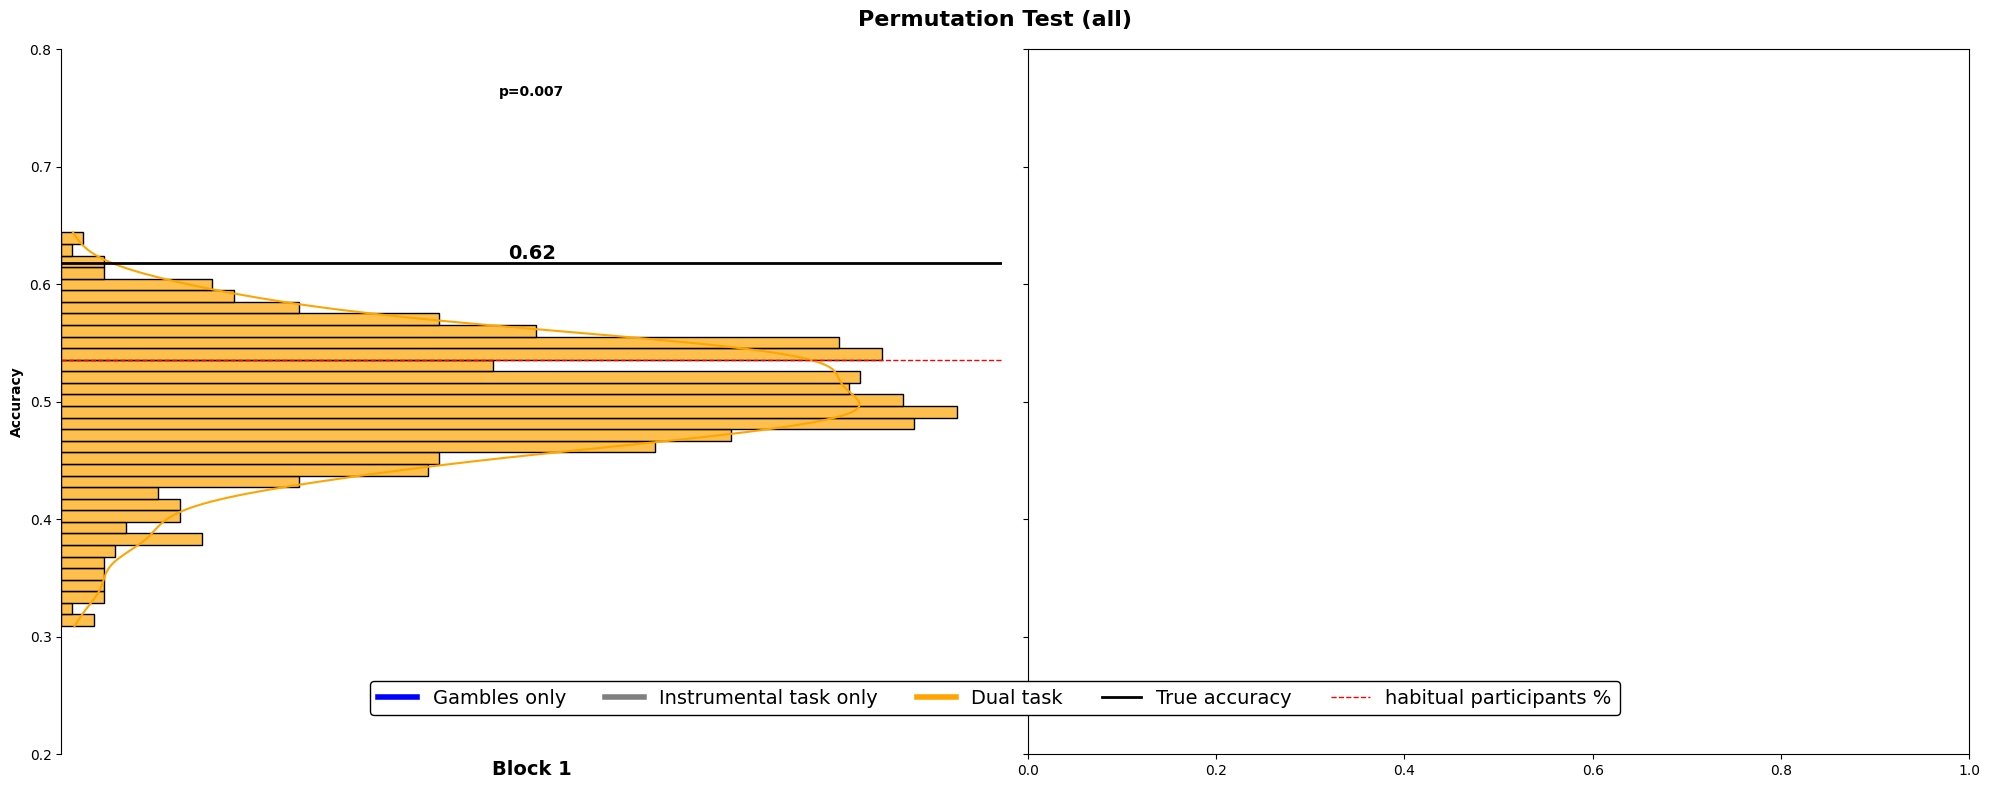

In [288]:
# for type_ in ['short', 'long', 'all']:    
for type_ in ['all']:    
    # Assuming LOOCV_SVC_results is defined
    loocv_results_long = LOOCV_SVC_results[type_]

    # Prepare the data
    blocks = list(loocv_results_long.keys())
    all_data = []

    for block in blocks:
        permuted_accuracies = loocv_results_long['run1']['permutations']['permuted_accuracies']
        block_data = pd.DataFrame({'Accuracy': permuted_accuracies, 'Block': f'Block {block}'})
        all_data.append(block_data)

    df = pd.concat(all_data)

    # Set up the plot
    # fig, axes = plt.subplots(1, len(blocks), figsize=(20, 8), sharey=True)
    fig, axes = plt.subplots(1, len(blocks)+1, figsize=(20, 8), sharey=True) # The +1 is just to work with more than 1 axis for now, change later...
    fig.subplots_adjust(wspace=0)

    pal = sns.color_palette("coolwarm", n_colors=len(blocks))

    # Create the ridge plot
    for i, (ax, block) in enumerate(zip(axes, blocks)):
        data = df[df['Block'] == f'Block {block}']['Accuracy']
        true_acc = loocv_results_long[block]['accuracy']
        p_value = loocv_results_long[block]['permutations']['p_value']
        
        if block in [1, 5]:
            hist_color = 'blue'
            label = 'gamble only'
        elif block in [2, 3]:
            hist_color = 'gray'
            label = 'instrumental only'
        else:
            hist_color = 'orange'
            label = 'dual'
        # # Plot the KDE
        # sns.kdeplot(y=data, fill=True, color=pal[i], alpha=0.7, 
        #             linewidth=0.5, ax=ax)
        # Plot the KDE
        sns.histplot(y=data, fill=True, alpha=0.7, 
                    ax=ax, kde=True, binwidth=0.01, color=hist_color, label=label)
        
        # Remove top, right, and bottom spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        # ax.spines['left'].set_visible(False)  # Add this line to remove the left spine

        # Remove x-axis ticks
        ax.set_xticks([])
        
        # Add the block label
        ax.set_xlabel(f'Block {i+1}', fontweight='bold', fontsize=14)
        
        # Add the true accuracy line
        ax.axhline(y=true_acc, color='black', linewidth=2)
        # Add majorit class line:
        majority_class_prop = 1 - loocv_results_long[block]['y_true'].mean() if loocv_results_long[block]['y_true'].mean() > 0.5 else 1 - loocv_results_long[block]['y_true'].mean()
        ax.axhline(y=majority_class_prop, color='red', linewidth=1, linestyle='--', label='habitual participants %')

        # print the true accuracy above the line:
        ax.text(0.5, true_acc, f'{true_acc:.2f}', ha='center', va='bottom', 
                transform=ax.get_yaxis_transform(), fontsize=14, fontweight='bold')
        
        # Add the p-value
        fontweight = 'bold' if p_value < 0.05 else 'normal'
        # make black if <0.05, dark grey if <0.1, light grey if >0.1
        fontcolor = 'black' if p_value < 0.05 else (51/255, 51/255, 51/255) if p_value < 0.1 else 'lightgrey'
        ax.text(0.5, 0.95, f'p={p_value:.3g}', ha='center', va='top', transform=ax.transAxes, fontweight=fontweight, color=fontcolor)

    # Set y-axis limits and label
    axes[0].set_ylim(0.2, 0.8)
    axes[0].set_ylabel('Accuracy', fontweight='bold')

    # add a custom legend with blue, grey and orange:
    legend_elements = [Line2D([0], [0], color='blue', lw=4, label='Gambles only'),
                    Line2D([0], [0], color='gray', lw=4, label='Instrumental task only'),
                    Line2D([0], [0], color='orange', lw=4, label='Dual task'),
                    Line2D([0], [0], color='black', lw=2, label='True accuracy', linestyle='-'),
                    Line2D([0], [0], color='red', lw=1, label='habitual participants %', linestyle='--')]
                    
    fig.legend(handles=legend_elements, fontsize=14, framealpha=1, edgecolor='black',facecolor='white', ncol=5, loc='center', bbox_transform=fig.transFigure, bbox_to_anchor=(0.5, 0.12))

    # Add title
    fig.suptitle(f'Permutation Test ({type_})', fontweight='bold', fontsize=16)

    plt.tight_layout()
    plt.show()